# LightGBM

The goal is to:
- train a baseline model
- evaluate performance using AUROC and AUPRC
- establish a reference for future feature comparisons (to also see which set of features wors best for this problem)


## Dataset A

In [1]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from utils import run_shap_analysis
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score

/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv("../data/dataset_A_train.csv")
val_df = pd.read_csv("../data/dataset_A_val.csv")
test_df = pd.read_csv("../data/dataset_A_test.csv")

print(train_df.shape, val_df.shape, test_df.shape)

(5707, 225) (1446, 225) (1815, 225)


### Prep Features

We separate features and labels and remove non-feature columns such as peptide and HLA identifiers.

In [3]:
drop_cols = ["peptide", "HLA", "hla_sequence", "index"]

# split features and labels
X_train = train_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_train = train_df["Label"]

X_val = val_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_val = val_df["Label"]

X_test = test_df.drop(columns=drop_cols + ["Label"], errors="ignore")
y_test = test_df["Label"]

# 🔹 combine to ensure consistent encoding
X_all = pd.concat([X_train, X_val, X_test])

# find categorical (object) columns
cat_cols = X_all.select_dtypes(include=["object"]).columns

# convert to category + encode
for col in cat_cols:
    X_all[col] = X_all[col].astype("category")
    X_all[col] = X_all[col].cat.codes

# split back
X_train = X_all.iloc[:len(X_train)]
X_val   = X_all.iloc[len(X_train):len(X_train)+len(X_val)]
X_test  = X_all.iloc[len(X_train)+len(X_val):]

print(X_train.shape)

(5707, 220)


### Model Training

We train a LightGBM classifier using the training set and monitor performance on the validation set.

In [4]:
evals_result = {}

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.record_evaluation(evals_result)]
)

[LightGBM] [Info] Number of positive: 2564, number of negative: 3143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003969 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35475
[LightGBM] [Info] Number of data points in the train set: 5707, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449273 -> initscore=-0.203609
[LightGBM] [Info] Start training from score -0.203609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


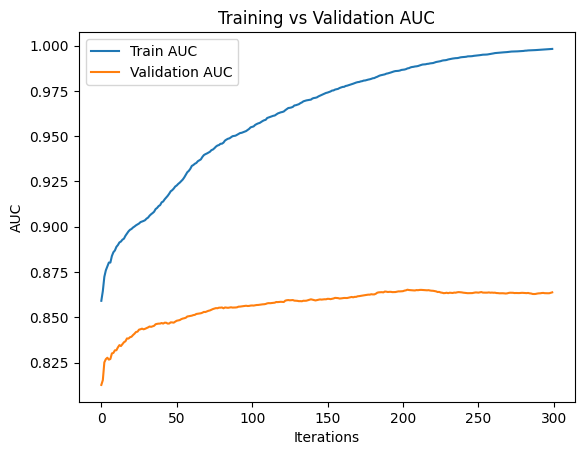

In [5]:
# Learning curve
train_auc = evals_result['training']['auc']
val_auc = evals_result['valid_1']['auc']

plt.plot(train_auc, label="Train AUC")
plt.plot(val_auc, label="Validation AUC")
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.legend()
plt.title("Training vs Validation AUC")
plt.show()

In [6]:
y_pred_proba_A = model.predict_proba(X_test)[:, 1]

auc_A = roc_auc_score(y_test, y_pred_proba_A)
auprc_A = average_precision_score(y_test, y_pred_proba_A)

print("Dataset A Test AUC:", auc_A)
print("Dataset A Test AUPRC:", auprc_A)

Dataset A Test AUC: 0.8705662858934291
Dataset A Test AUPRC: 0.8124957889609224


In [7]:
# basic feature importance
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head(20))

                       feature  importance
14            Peptide_BLOSUM10         145
8              Peptide_BLOSUM4         141
32                 Peptide_KF9         136
107  Peptide_instability_index         130
33                Peptide_KF10         123
53             Peptide_ProtFP7         116
18                  Peptide_F1         112
13             Peptide_BLOSUM9         108
55                 Peptide_SV1         107
54             Peptide_ProtFP8         107
4                  Peptide_AF5         103
26                 Peptide_KF3         101
94              Peptide_VSTPV4         101
100                 Peptide_Z4          98
35             Peptide_MSWHIM2          98
2                  Peptide_AF3          95
92              Peptide_VSTPV2          93
72              Peptide_SVGER6          93
30                 Peptide_KF7          92
12             Peptide_BLOSUM8          92


/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


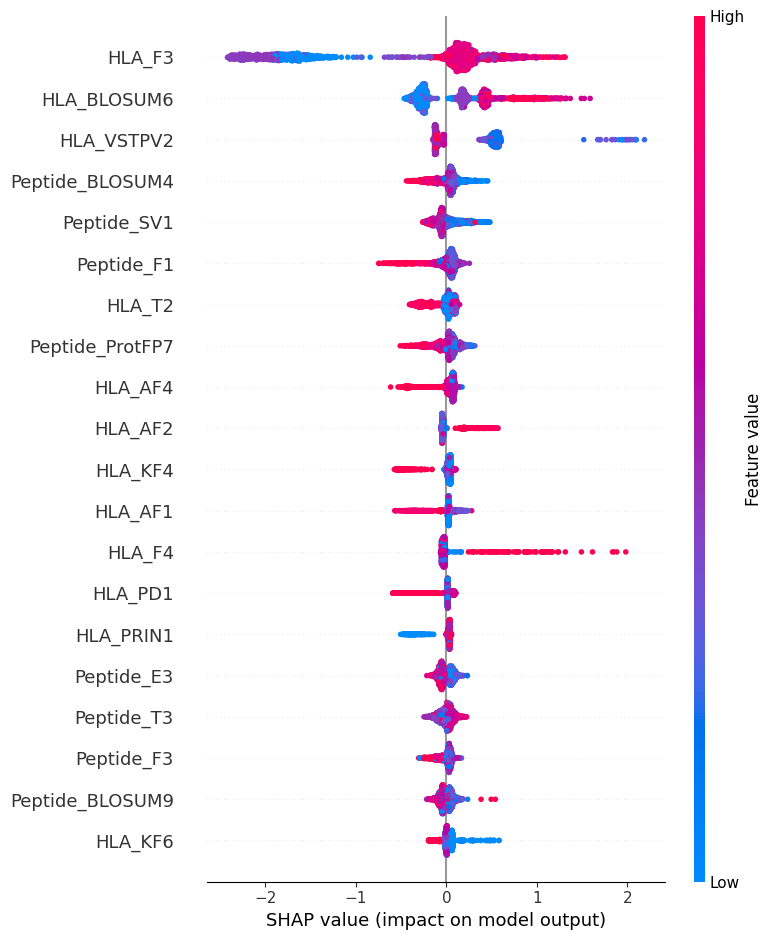

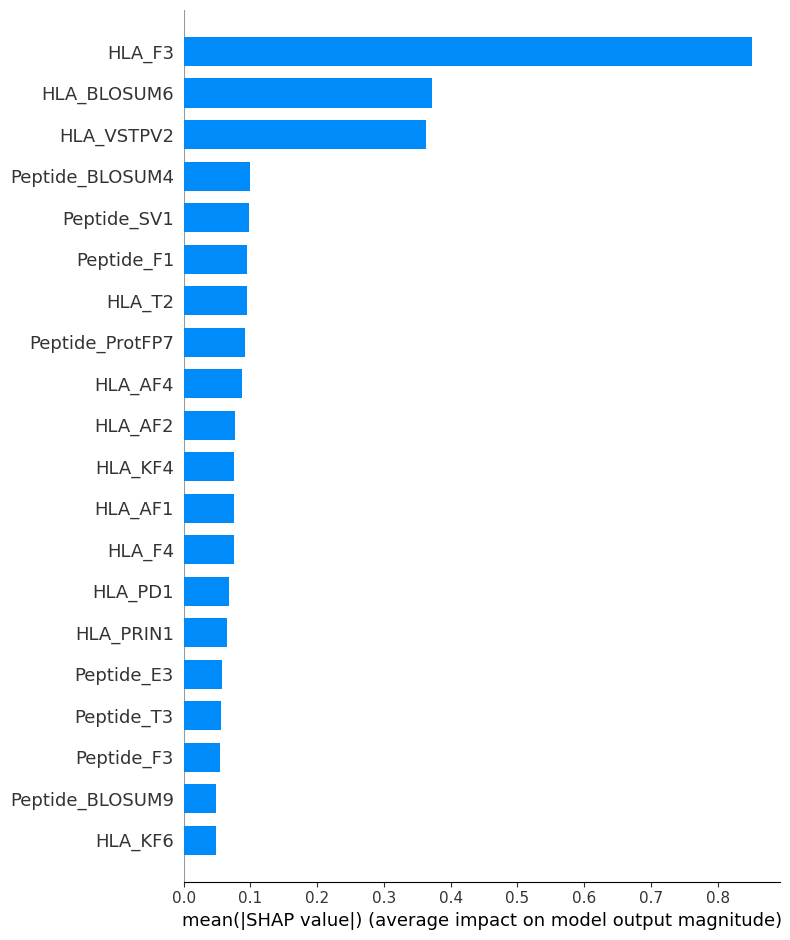

In [8]:
run_shap_analysis(model, X_test)

In [9]:
joblib.dump(
    model,
    "../models/lightgbm_datasetA_v1.pkl"
)

['../models/lightgbm_datasetA_v1.pkl']

## Dataset B

In [10]:
train_df_B = pd.read_csv("../data/dataset_B_train.csv")
val_df_B = pd.read_csv("../data/dataset_B_val.csv")
test_df_B = pd.read_csv("../data/dataset_B_test.csv")

print(train_df_B.shape, val_df_B.shape, test_df_B.shape)

(5707, 295) (1446, 295) (1815, 295)


### Prep Features

In [11]:
drop_cols = ["peptide", "HLA", "hla_sequence", "index"]

# split features and labels
X_train_B = train_df_B.drop(columns=drop_cols + ["Label"], errors="ignore")
y_train_B = train_df_B["Label"]

X_val_B = val_df_B.drop(columns=drop_cols + ["Label"], errors="ignore")
y_val_B = val_df_B["Label"]

X_test_B = test_df_B.drop(columns=drop_cols + ["Label"], errors="ignore")
y_test_B = test_df_B["Label"]

# combine to ensure consistent encoding
X_all_B = pd.concat([X_train_B, X_val_B, X_test_B])

# find categorical (object) columns
cat_cols_B = X_all_B.select_dtypes(include=["object"]).columns

# convert to category + encode
for col in cat_cols_B:
    X_all_B[col] = X_all_B[col].astype("category")
    X_all_B[col] = X_all_B[col].cat.codes

# split back
n_train = len(X_train_B)
n_val = len(X_val_B)

X_train_B = X_all_B.iloc[:n_train]
X_val_B   = X_all_B.iloc[n_train:n_train + n_val]
X_test_B  = X_all_B.iloc[n_train + n_val:]

print(X_train_B.shape, X_val_B.shape, X_test_B.shape)

(5707, 290) (1446, 290) (1815, 290)


### Model Training

In [12]:
evals_result_B = {}

model_B = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_B.fit(
    X_train_B,
    y_train_B,
    eval_set=[(X_train_B, y_train_B), (X_val_B, y_val_B)],
    eval_metric="auc",
    callbacks=[lgb.record_evaluation(evals_result_B)]
)

[LightGBM] [Info] Number of positive: 2564, number of negative: 3143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8963
[LightGBM] [Info] Number of data points in the train set: 5707, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449273 -> initscore=-0.203609
[LightGBM] [Info] Start training from score -0.203609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


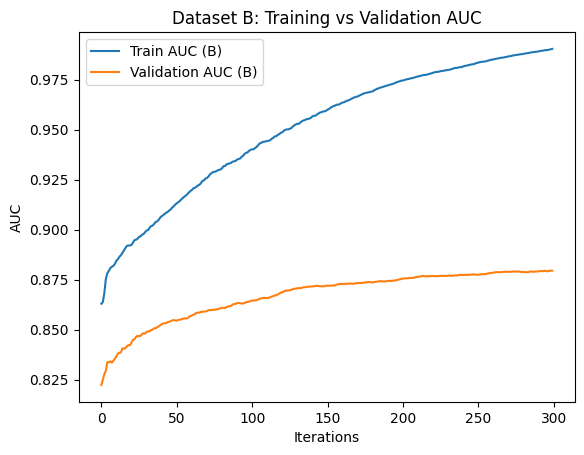

In [13]:
# Learning curve for Dataset B
train_auc_B = evals_result_B['training']['auc']
val_auc_B = evals_result_B['valid_1']['auc']

plt.plot(train_auc_B, label="Train AUC (B)")
plt.plot(val_auc_B, label="Validation AUC (B)")
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.legend()
plt.title("Dataset B: Training vs Validation AUC")
plt.show()

In [14]:
y_pred_proba_B = model_B.predict_proba(X_test_B)[:, 1]


auc_B = roc_auc_score(y_test_B, y_pred_proba_B)
auprc_B = average_precision_score(y_test_B, y_pred_proba_B)

print("Dataset B Test AUC:", auc_B)
print("Dataset B Test AUPRC:", auprc_B)

Dataset B Test AUC: 0.8863778864146248
Dataset B Test AUPRC: 0.8375397201892979


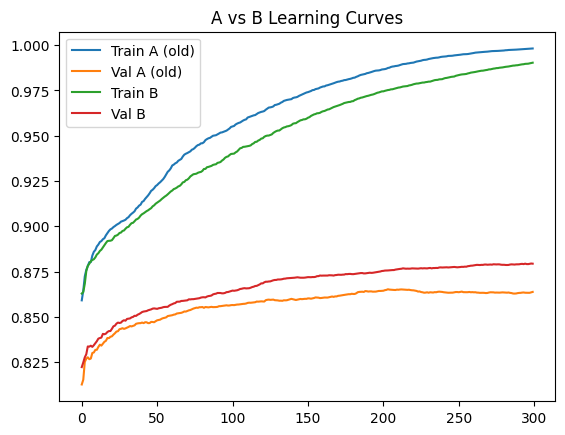

In [15]:
plt.plot(train_auc, label="Train A (old)")
plt.plot(val_auc, label="Val A (old)")

plt.plot(train_auc_B, label="Train B")
plt.plot(val_auc_B, label="Val B")

plt.legend()
plt.title("A vs B Learning Curves")
plt.show()

In [16]:
# basic feature importance for Dataset B
importance_B = pd.DataFrame({
    "feature": X_train_B.columns,
    "importance": model_B.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_B.head(20))

               feature  importance
106  PeptidePos_p6_f17         181
16   PeptidePos_p1_f17         172
52   PeptidePos_p3_f17         161
124  PeptidePos_p7_f17         155
70   PeptidePos_p4_f17         153
48   PeptidePos_p3_f13         151
88   PeptidePos_p5_f17         150
102  PeptidePos_p6_f13         143
3     PeptidePos_p1_f4         137
142  PeptidePos_p8_f17         136
138  PeptidePos_p8_f13         135
160  PeptidePos_p9_f17         134
120  PeptidePos_p7_f13         133
66   PeptidePos_p4_f13         126
57    PeptidePos_p4_f4         122
39    PeptidePos_p3_f4         115
93    PeptidePos_p6_f4         114
34   PeptidePos_p2_f17         113
84   PeptidePos_p5_f13         111
156  PeptidePos_p9_f13         111


/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


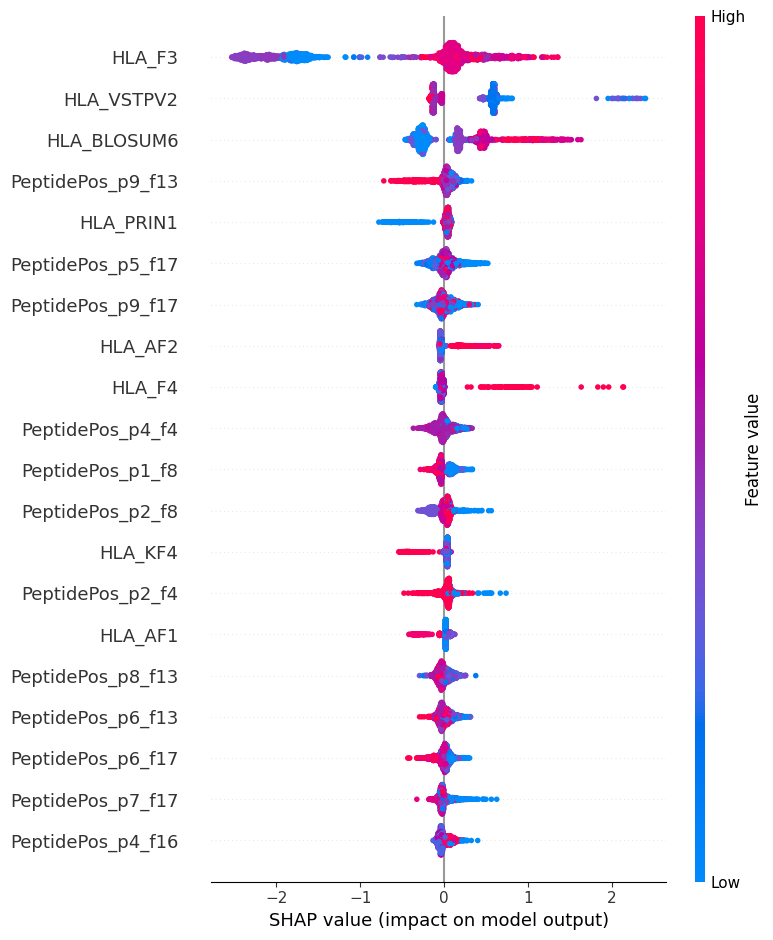

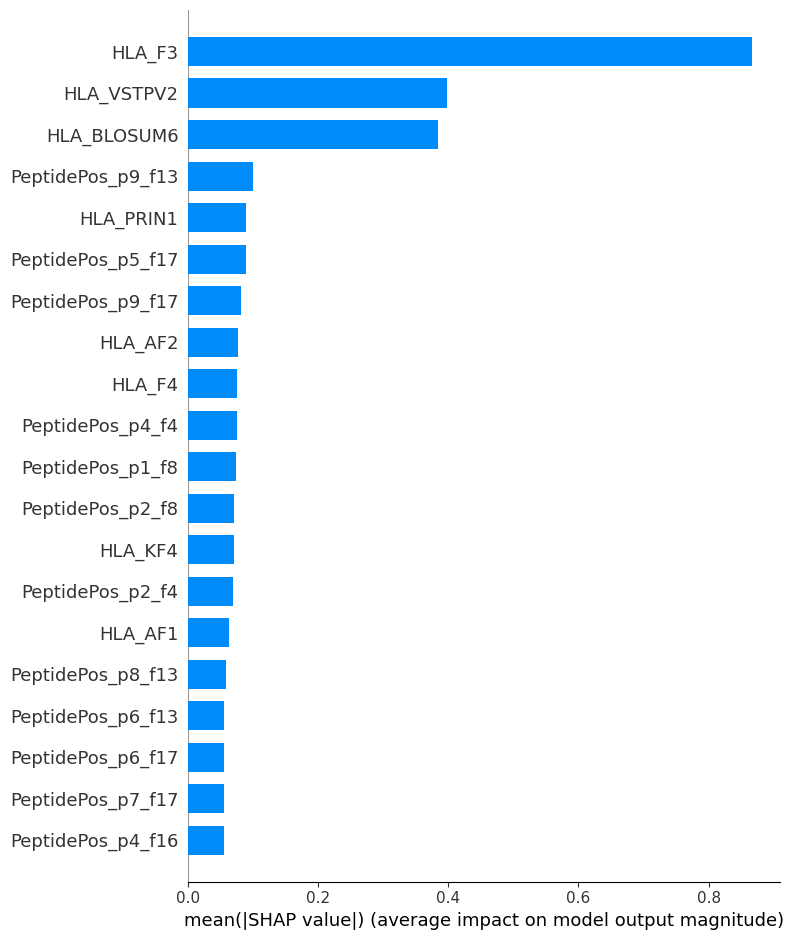

In [17]:
run_shap_analysis(model_B, X_test_B)

In [18]:
joblib.dump(
    model_B,
    "../models/lightgbm_datasetB_v1.pkl"
)

['../models/lightgbm_datasetB_v1.pkl']

In [21]:
print(evals_result_B['training']['auc'][:5])

[np.float64(0.8628948116881087), np.float64(0.8637190190121127), np.float64(0.8682586740313393), np.float64(0.8752813125569885), np.float64(0.8781889948840079)]


In [22]:
print(y_pred_proba_B[:10])

[0.02225203 0.12768905 0.01793149 0.04285472 0.04335877 0.00677477
 0.00644677 0.0210185  0.03426161 0.01241393]


In [23]:
print(X_train_B.shape[1])

290
